In [2]:
import torch

if torch.cuda.is_available():
    print("CUDA is available. The model can use the GPU.")
else:
    print("CUDA is not available. The model will run on the CPU.")

CUDA is available. The model can use the GPU.


In [3]:
# Checking if the device is a GPU
from ultralytics import YOLO
model = YOLO("yolov8n.pt")  # or any model
print(f"Model parameter device: {next(model.parameters()).device}")

Model parameter device: cpu


In [4]:
# Setting the model to use GPU
model = YOLO("yolov8n.pt").to("cuda:0")
print(f"Model parameter device: {next(model.parameters()).device}")  # Should print cuda:0

Model parameter device: cuda:0


In [5]:
import os
import torch
import time
from ultralytics import YOLO
import torchvision
from IPython.display import display
import random

# Ensure GPU selection
device = "cuda" if torch.cuda.is_available() else "cpu"
display(f"Using device: {device}")
torch.cuda.set_device(0)  # Explicitly set the GPU device


# Set the local path to the COCO dataset (adjust if your structure differs)
coco_dir = r"C:\Users\achyu\COCO"
val_dir = os.path.join(coco_dir, "val2017")

# Using a specific image from the validation set.
# Set the local path to the COCO dataset's validation folder


# List all image files in the validation directory (adjust extensions if needed)
image_files = [f for f in os.listdir(val_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

# Choose a random image file from the list
if image_files:
    example_image = os.path.join(val_dir, random.choice(image_files))
    print(f"Using image: {example_image}")
else:
    print("No image files found in the directory.")

# Load YOLO Model
try:
    model = YOLO("yolo11n.pt").to(device)
    display("Model loaded successfully.")
except Exception as e:
    display(f"Error loading model: {e}")

# Running prediction on the sample image.
start_time = time.time()
try:
    results = model.predict(source=example_image, save=True, imgsz=640, conf=0.25)
except Exception as e:
    print(f"An error occurred during prediction: {e}")

# Display the results
results[0].show()

'Using device: cuda'

Using image: C:\Users\achyu\COCO\val2017\000000018770.jpg


'Model loaded successfully.'


image 1/1 C:\Users\achyu\COCO\val2017\000000018770.jpg: 448x640 1 person, 1 tie, 91.1ms
Speed: 9.0ms preprocess, 91.1ms inference, 181.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs\detect\predict5


In [6]:
import os
import random
import torch
import time
from ultralytics import YOLO
from IPython.display import display

# Ensure GPU selection
device = "cuda" if torch.cuda.is_available() else "cpu"
display(f"Using device: {device}")
torch.cuda.set_device(0)  # Explicitly set the GPU device

# Set the local path to the COCO dataset's validation folder
# (adjust the path if your folder structure is different)
coco_dir = r"C:\Users\achyu\COCO"
val_dir = os.path.join(coco_dir, "val2017")

# List all image files in the validation directory (adjust extensions if needed)
image_files = [f for f in os.listdir(val_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

# Choose a random image file from the list
if image_files:
    example_image = os.path.join(val_dir, random.choice(image_files))
    print(f"Using image: {example_image}")
else:
    raise Exception("No image files found in the directory.")

# Load YOLO model (using your YOLO11 model here)
try:
    model = YOLO("yolo11n.pt").to(device)
    display("Model loaded successfully.")
except Exception as e:
    display(f"Error loading model: {e}")

# Run prediction with SAHI slicing enabled.
# Note: The additional keyword arguments (sahi=True, sahi_conf_thresh, etc.)
# enable SAHI's sliced inference, which helps with large images or small objects.
start_time = time.time()
try:
    results = model.predict(
        source=example_image,
        save=True,
        imgsz=640,
        conf=0.25,
        sahi=True,                 # Enable SAHI
        sahi_conf_thresh=0.25,       # Confidence threshold for SAHI
        sahi_overlap_ratio=0.2,      # Slicing overlap ratio (20% overlap)
        sahi_min_box_area=0,         # Minimum box area; use 0 to keep all
    )
except Exception as e:
    print(f"An error occurred during prediction: {e}")

print(f"Inference took {time.time() - start_time:.2f} seconds")

# Display the result for the first image from SAHI-sliced output; 
# this image now has merged bounding boxes from the slices.
results[0].show()

'Using device: cuda'

Using image: C:\Users\achyu\COCO\val2017\000000463690.jpg


'Model loaded successfully.'

An error occurred during prediction: 'sahi' is not a valid YOLO argument. Similar arguments are i.e. ['mosaic=1.0'].
'sahi_overlap_ratio' is not a valid YOLO argument. Similar arguments are i.e. ['overlap_mask=True'].
'sahi_min_box_area' is not a valid YOLO argument. 
'sahi_conf_thresh' is not a valid YOLO argument. 

    Arguments received: ['yolo', '--f=c:\\Users\\achyu\\AppData\\Roaming\\jupyter\\runtime\\kernel-v3cbaed912ff482c4ec26c260e3bd390ee03e4e649.json']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of ['detect', 'classify', 'pose', 'obb', 'segment']
                MODE (required) is one of ['val', 'benchmark', 'track', 'train', 'predict', 'export']
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at https://docs.ultralytics.com/usage/cfg or with 'yolo cfg'

    1. Train a detection model for 10 epoc

In [7]:
from sahi.utils.file import download_from_url
from sahi.utils.ultralytics import download_yolo11n_model

# Download YOLO11 model
model_path = "models/yolo11n.pt"
download_yolo11n_model(model_path)

# Download test images
download_from_url(
    "https://raw.githubusercontent.com/obss/sahi/main/demo/demo_data/small-vehicles1.jpeg",
    "demo_data/small-vehicles1.jpeg",
)
download_from_url(
    "https://raw.githubusercontent.com/obss/sahi/main/demo/demo_data/terrain2.png",
    "demo_data/terrain2.png",
)

In [8]:
from sahi import AutoDetectionModel

detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=model_path,
    confidence_threshold=0.3,
    device="cpu",  # or 'cuda:0'
)

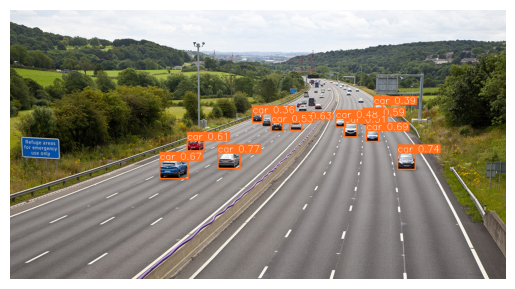

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sahi.predict import get_prediction


def read_image(image_path):
    """Reads an image from a file and converts it to a NumPy array."""
    image = cv2.imread(image_path)  # Read image using OpenCV
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB format
    return image

# Example usage
image_np = read_image("demo_data/small-vehicles1.jpeg")
result_with_np_image = get_prediction(image_np, detection_model)

# With an image path
result = get_prediction("demo_data/small-vehicles1.jpeg", detection_model)

# With a numpy image
result_with_np_image = get_prediction(read_image("demo_data/small-vehicles1.jpeg"), detection_model)

result.export_visuals(export_dir="demo_data/")
img = cv2.imread("demo_data/prediction_visual.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for proper colors

plt.imshow(img)
plt.axis("off")
plt.show()


In [10]:
from sahi.predict import get_sliced_prediction

result = get_sliced_prediction(
    "demo_data/small-vehicles1.jpeg",
    detection_model,
    slice_height=256,
    slice_width=256,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
)

Performing prediction on 15 slices.


In [11]:
# Access the object prediction list
object_prediction_list = result.object_prediction_list

# Convert to COCO annotation, COCO prediction, imantics, and fiftyone formats
result.to_coco_annotations()[:3]
result.to_coco_predictions(image_id=1)[:3]
result.to_imantics_annotations()[:3]
result.to_fiftyone_detections()[:3]

[<Detection: {
     'id': '684398d6120498cd57ac5287',
     'attributes': {},
     'tags': [],
     'label': 'car',
     'bounding_box': [
         0.41927349076288917,
         0.5328894779599946,
         0.044562014747648204,
         0.05713174754175646,
     ],
     'mask': None,
     'mask_path': None,
     'confidence': 0.9221274256706238,
     'index': None,
 }>,
 <Detection: {
     'id': '684398d6120498cd57ac5288',
     'attributes': {},
     'tags': [],
     'label': 'car',
     'bounding_box': [
         0.7796507846103625,
         0.5322432813973262,
         0.03877938731332843,
         0.06210123259445716,
     ],
     'mask': None,
     'mask_path': None,
     'confidence': 0.8925062417984009,
     'index': None,
 }>,
 <Detection: {
     'id': '684398d6120498cd57ac5289',
     'attributes': {},
     'tags': [],
     'label': 'car',
     'bounding_box': [
         0.7173962396628848,
         0.4494141874642208,
         0.0259458991918671,
         0.04061950815135035,
 

In [12]:
from sahi.predict import predict
from PIL import Image
predict(
    model_type="ultralytics",
    model_path="path/to/yolo11n.pt",
    model_device="cuda:0",  # or 'cpu'
    model_confidence_threshold=0.4,
    source="demo_data/small-vehicles1.jpeg",  # Use an actual image file path
    slice_height=256,
    slice_width=256,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
)

Performing inference on images:   0%|          | 0/1 [00:00<?, ?it/s]

Performing prediction on 15 slices.


Performing inference on images: 100%|██████████| 1/1 [00:00<00:00,  2.48it/s]

Prediction time is: 357.20 ms
Prediction results are successfully exported to runs\predict\exp


In [1]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sahi.model import Yolov8DetectionModel
from sahi.predict import get_prediction

# ⚙️ Load your fine-tuned YOLOv8 model
model_path = r"E:\yolo_project\transfer_learning\yolo11n_finetuned_1.pt"
detection_model = Yolov8DetectionModel(
    model_path=model_path,
    confidence_threshold=0.3,  # Adjust as needed
    device="cuda:0" if cv2.cuda.getCudaEnabledDeviceCount() > 0 else "cpu",
)

# 📂 Randomly pick an image from your train set
train_dir = r"E:\yolo_project\transfer_learning\initial model\images\train"
image_list = [os.path.join(train_dir, f) for f in os.listdir(train_dir) if f.endswith((".jpg", ".png"))]
image_path = random.choice(image_list)

def read_image(image_path):
    """Reads an image and converts it to RGB format."""
    image = cv2.imread(image_path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 🧠 Run prediction using SAHI
result = get_prediction(image_path, detection_model)
result.export_visuals(export_dir="demo_data")

# 🖼️ Display prediction overlay
visual_path = os.path.join("demo_data", "prediction_visual.png")
vis_img = cv2.imread(visual_path)
vis_img = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)

plt.imshow(vis_img)
plt.axis("off")
plt.title(f"Predictions for {os.path.basename(image_path)}")
plt.show()


ModuleNotFoundError: No module named 'sahi.model'